In [1]:
import os
from constants import *
# from cleanvision import Imagelab
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Kaggle images

In [2]:
kaggle22_train = pd.read_csv(KAGGLE_HERBARIUM_22_TRAIN_CSV).drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Number of training samples in Kaggle Herbarium 22: {len(kaggle22_train)}")
kaggle22_val = pd.read_csv(KAGGLE_HERBARIUM_22_VAL_CSV).drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Number of validation samples in Kaggle Herbarium 22: {len(kaggle22_val)}")

kaggle22 = pd.concat([kaggle22_train, kaggle22_val]).reset_index(drop=True)

kaggle22_file_paths = [os.path.join(KAGGLE_HERBARIUM_22_TRAIN, file) for file in kaggle22['filename'].tolist()]
print(f"Number of images in Kaggle Herbarium 22: {len(kaggle22_file_paths)}")
kaggle22_file_paths[:5]
kaggle21_train = pd.read_csv(KAGGLE_HERBARIUM_21_TRAIN_CSV).drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Number of training samples in Kaggle Herbarium 21: {len(kaggle21_train)}")
kaggle21_val = pd.read_csv(KAGGLE_HERBARIUM_21_VAL_CSV).drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Number of validation samples in Kaggle Herbarium 21: {len(kaggle21_val)}")

kaggle21 = pd.concat([kaggle21_train, kaggle21_val]).reset_index(drop=True)

kaggle21_file_paths = [os.path.join(KAGGLE_HERBARIUM_21_TRAIN_CSV, file) for file in kaggle21['filename'].tolist()]
print(f"Number of images in Kaggle Herbarium 21 Train: {len(kaggle21_file_paths)}")
kaggle21_file_paths[:5]

Number of training samples in Kaggle Herbarium 22: 671817
Number of validation samples in Kaggle Herbarium 22: 167955
Number of images in Kaggle Herbarium 22: 839772
Number of training samples in Kaggle Herbarium 21: 1806207
Number of validation samples in Kaggle Herbarium 21: 451552
Number of images in Kaggle Herbarium 21 Train: 2257759


['/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/494/80/1123740.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/161/93/1242345.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/069/53/2238072.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/001/99/1458.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/219/79/344538.jpg']

In [3]:
(kaggle22_train.columns == kaggle22_val.columns).all()

np.True_

In [4]:
kaggle22_train.to_csv(KAGGLE_HERBARIUM_22_TRAIN_CSV, index=False)
kaggle22_train.to_json(KAGGLE_HERBARIUM_22_TRAIN_JSON, orient='records', lines=True)

kaggle22_val.to_csv(KAGGLE_HERBARIUM_22_VAL_CSV, index=False)
kaggle22_val.to_json(KAGGLE_HERBARIUM_22_VAL_JSON, orient='records', lines=True)

In [5]:
kaggle21_train = pd.read_csv(KAGGLE_HERBARIUM_21_TRAIN_CSV).drop(columns=['Unnamed: 0'])
print(f"Number of training samples in Kaggle Herbarium 21: {len(kaggle21_train)}")
kaggle21_val = pd.read_csv(KAGGLE_HERBARIUM_21_VAL_CSV).drop(columns=['Unnamed: 0'])
print(f"Number of validation samples in Kaggle Herbarium 21: {len(kaggle21_val)}")

kaggle21 = pd.concat([kaggle21_train, kaggle21_val]).reset_index(drop=True)

kaggle21_file_paths = [os.path.join(KAGGLE_HERBARIUM_21_TRAIN_CSV, file) for file in kaggle21['filename'].tolist()]
print(f"Number of images in Kaggle Herbarium 21 Train: {len(kaggle21_file_paths)}")
kaggle21_file_paths[:5]

Number of training samples in Kaggle Herbarium 21: 1806207
Number of validation samples in Kaggle Herbarium 21: 451552
Number of images in Kaggle Herbarium 21 Train: 2257759


['/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/494/80/1123740.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/161/93/1242345.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/069/53/2238072.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/001/99/1458.jpg',
 '/projectnb/herbdl/data/kaggle-herbaria/train_2021.csv/219/79/344538.jpg']

In [6]:
KAGGLE_FILEPATHS = kaggle22_file_paths + kaggle21_file_paths
print(f"Total number of images from Kaggle: {len(KAGGLE_FILEPATHS)}")

Total number of images from Kaggle: 3097531


In [7]:
# find the overlap between the two datasets
kaggle21_train['scientificName'] = kaggle21_train['scientificName'].str.lower()
kaggle22_train['scientificName'] = kaggle22_train['scientificName'].str.lower()

# find the overlap in the scientific names
overlap = kaggle21_train['scientificName'].isin(kaggle22_train['scientificName'])
print(f"Number of overlapping scientific names: {overlap.sum()}")

Number of overlapping scientific names: 887901


In [8]:
kaggle_21_species = set(kaggle21['scientificName'].unique())
kaggle_22_species = set(kaggle22['scientificName'].unique())
print(f"Number of unique species in Kaggle Herbarium 21: {len(kaggle_21_species)}")
print(f"Number of unique species in Kaggle Herbarium 22: {len(kaggle_22_species)}")

overlap_species = kaggle_21_species.intersection(kaggle_22_species)
print(f"Number of overlapping species: {len(overlap_species)}")

Number of unique species in Kaggle Herbarium 21: 61338
Number of unique species in Kaggle Herbarium 22: 15501
Number of overlapping species: 12251


## De-duplicating Kaggle datasets and saving

In [9]:
from cleanvision import Imagelab
# Specify path to folder containing the image files in your dataset
save_path = "./results"

imagelab = Imagelab.load(save_path)

/projectnb/herbdl/workspaces/faridkar/.conda/envs/herb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded Imagelab


In [10]:
exact_duplicate_sets = imagelab.info["exact_duplicates"]["sets"]

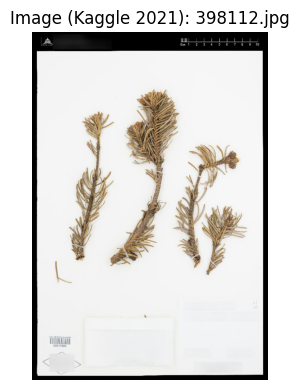

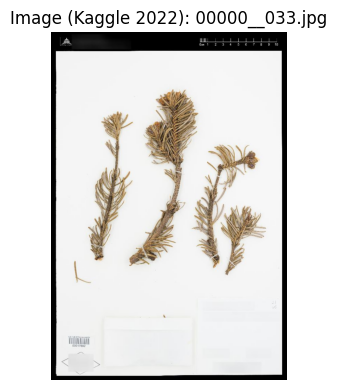

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import os

def display_image(filepath):
    """
    Display an image from a filepath in a Jupyter notebook.
    
    Parameters:
    filepath (str): Path to the image file
    """
    try:
        # Open the image
        img = Image.open(filepath)
        
        # Create a figure and display the image
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        if '2021' in filepath:
            plt.title(f"Image (Kaggle 2021): {os.path.basename(filepath)}")
        elif '2022' in filepath:
            plt.title(f"Image (Kaggle 2022): {os.path.basename(filepath)}")
       
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found.")
    except Exception as e:
        print(f"Error loading image: {e}")

# Example usage:

sample_index = 2

display_image(exact_duplicate_sets[sample_index][0])
display_image(exact_duplicate_sets[sample_index][1])


In [12]:
from PIL import Image
import torch
from torchvision import transforms
from tqdm import tqdm

def check_duplicate_images(image_pairs):
    """
    Check if pairs of images are identical.
    
    Parameters:
    image_pairs (list): A list of [N, 2] image path pairs to compare
                       e.g., [['path1.jpg', 'path2.jpg'], ['path3.jpg', 'path4.jpg']]
    
    Returns:
    list: A list of dictionaries containing comparison results for each pair
    """
    transform = transforms.ToTensor()
    results = []
    
    for idx, (path1, path2) in tqdm(enumerate(image_pairs), total=len(image_pairs), desc="Checking image pairs"):
        result = {
            'pair_index': idx,
            'image1': path1,
            'image2': path2,
            'identical': False,
            'error': None
        }
        
        try:
            # Load images
            img1 = Image.open(path1)
            img2 = Image.open(path2)
            
            # Convert to tensors
            tensor1 = transform(img1)
            tensor2 = transform(img2)
            
            result['shape1'] = tuple(tensor1.shape)
            result['shape2'] = tuple(tensor2.shape)
            
            # Check if identical
            if tensor1.shape != tensor2.shape:
                result['identical'] = False
                result['error'] = 'Different dimensions'
            else:
                result['identical'] = torch.equal(tensor1, tensor2)
                
                # Calculate differences if not identical
                if not result['identical']:
                    diff = torch.abs(tensor1 - tensor2)
                    result['max_diff'] = torch.max(diff).item()
                    result['mean_diff'] = torch.mean(diff).item()
                    
        except Exception as e:
            result['error'] = str(e)
        
        results.append(result)
    
    return results

# image_pairs = exact_duplicate_sets[10000:20000]

# results = check_duplicate_images(image_pairs)

# # Print results
# for result in results:
#     # print(f"\nPair {result['pair_index']}: {result['image1']} vs {result['image2']}")
#     if result['error']:
#         print(f"  Error: {result['error']}")
#     else:
#         # print(f"  Shapes: {result['shape1']} vs {result['shape2']}")
#         # print(f"  Identical: {result['identical']}")
#         if not result['identical'] and 'max_diff' in result:
#             print(f"  Max difference: {result['max_diff']:.6f}")
#             print(f"  Mean difference: {result['mean_diff']:.6f}")

# # Count duplicates
# duplicates = sum(1 for r in results if r['identical'])
# print(f"\n{duplicates} out of {len(results)} pairs are identical")

KeyboardInterrupt: 

In [13]:
kaggle22['filename'] = kaggle22['filename'].apply(lambda x: os.path.join(KAGGLE_HERBARIUM_22_TRAIN, x))
kaggle21['filename'] = kaggle21['filename'].apply(lambda x: os.path.join(KAGGLE_HERBARIUM_21_TRAIN, x))

In [14]:
kaggle_df = pd.concat([kaggle22, kaggle21])
kaggle_df = kaggle_df.reset_index(drop=True)
kaggle_df.rename(columns={"filename": "filepath"}, inplace=True)
kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3097531 entries, 0 to 3097530
Data columns (total 8 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   image_id               object
 1   filepath               object
 2   caption                object
 3   scientificName         object
 4   family                 object
 5   genus                  object
 6   species                object
 7   scientificNameEncoded  int64 
dtypes: int64(1), object(7)
memory usage: 189.1+ MB


In [15]:
import numpy as np

images_to_delete = [np.random.choice(duplicate_set) for duplicate_set in exact_duplicate_sets]
print(f"Number of images to delete: {len(images_to_delete)}")

to_delete_indices = kaggle_df[kaggle_df['filepath'].isin(images_to_delete)].index

Number of images to delete: 229215


In [16]:
kaggle_df = kaggle_df.drop(index=to_delete_indices).reset_index(drop=True)
kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2868316 entries, 0 to 2868315
Data columns (total 8 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   image_id               object
 1   filepath               object
 2   caption                object
 3   scientificName         object
 4   family                 object
 5   genus                  object
 6   species                object
 7   scientificNameEncoded  int64 
dtypes: int64(1), object(7)
memory usage: 175.1+ MB


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

kaggle_df['scientificNameEncoded'] = le.fit_transform(kaggle_df['scientificName'])

kaggle_df.head()

,image_id,filepath,caption,scientificName,family,genus,species,scientificNameEncoded
0,12640__012,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/126/40/12640__012.jpg,"This is an image of species cordovensis, in the genus Roldana of family Asteraceae. It is part of the collection of institution K.",Asteraceae Roldana cordovensis,Asteraceae,Roldana,cordovensis,9329
1,02962__081,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/029/62/02962__081.jpg,"This is an image of species whitneyi, in the genus Carex of family Cyperaceae. It is part of the collection of institution COLO.",Cyperaceae Carex whitneyi,Cyperaceae,Carex,whitneyi,18686
2,08401__098,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/084/01/08401__098.jpg,"This is an image of species philadelphicum, in the genus Lilium of family Liliaceae. It is part of the collection of institution COLO.",Liliaceae Lilium philadelphicum,Liliaceae,Lilium,philadelphicum,33709
3,02707__054,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/027/07/02707__054.jpg,"This is an image of species hoodii, in the genus Carex of family Cyperaceae. It is part of the collection of institution ID.",Cyperaceae Carex hoodii,Cyperaceae,Carex,hoodii,18325
4,10779__004,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/107/79/10779__004.jpg,"This is an image of species spectabilis, in the genus Penstemon of family Plantaginaceae. It is part of the collection of institution NY.",Plantaginaceae Penstemon spectabilis,Plantaginaceae,Penstemon,spectabilis,47867


In [19]:
kaggle_df.to_csv(DATA_PATH + "kaggle-herbaria/index.csv", index=False)

### Misc

In [46]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(kaggle_df, test_size=0.20, random_state=42)

train.shape, val.shape

((2294652, 8), (573664, 8))

In [33]:
train = train[['filepath', 'scientificNameEncoded']].sort_index()
train.head()

,filepath,scientificNameEncoded
0,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/126/40/12640__012.jpg,9329
1,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/029/62/02962__081.jpg,18686
2,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/084/01/08401__098.jpg,33709
3,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/027/07/02707__054.jpg,18325
4,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2022/train_images/107/79/10779__004.jpg,47867


In [34]:
train[train['filepath'] == "/projectnb/herbdl/data/kaggle-herbaria/herbarium-2021/train/images/047/37/1047497.jpg"]

,filepath,scientificNameEncoded
1580617,/projectnb/herbdl/data/kaggle-herbaria/herbarium-2021/train/images/047/37/1047497.jpg,2586


In [38]:
train['scientificNameEncoded'].nunique(), val['scientificNameEncoded'].nunique()

(64230, 52706)

In [9]:
kaggle_train = "/projectnb/herbdl/data/kaggle-herbaria/train.json"
kaggle_val = "/projectnb/herbdl/data/kaggle-herbaria/val.json"

kaggle_train_df = pd.read_json(kaggle_train, lines=True)
kaggle_val_df = pd.read_json(kaggle_val, lines=True)

kaggle_train_df.shape, kaggle_val_df.shape

((2249230, 3), (562308, 3))

In [10]:
kaggle_train_df['scientificNameEncoded'].nunique(), kaggle_val_df['scientificNameEncoded'].nunique()

(64113, 57094)

In [14]:
from datasets import load_dataset

seed = 42
data_files = {
    "train": kaggle_train,
    "validation": kaggle_val,
}

dataset = load_dataset(
            "json",
            data_files=data_files,
            cache_dir="./data_cache",
        )

dataset['train'].features

Generating train split: 2249230 examples [00:03, 685767.78 examples/s]
Generating validation split: 562308 examples [00:00, 745475.28 examples/s]


{'filepath': Value('string'),
 'scientificName': Value('string'),
 'scientificNameEncoded': Value('int64')}

In [15]:
subset_sizes = [50000, 100000, 200000, 300000, 400000, 500000]

for size in subset_sizes:
    eval_subset = dataset["validation"].shuffle(seed=42).select(range(size))
    print(f"Unique species for eval subset of size {size}: {len(eval_subset.unique('scientificNameEncoded'))}")
    
    

Flattening the indices: 100%|██████████| 50000/50000 [00:01<00:00, 31847.19 examples/s]


Unique species for eval subset of size 50000: 21745


Flattening the indices: 100%|██████████| 100000/100000 [00:03<00:00, 31699.12 examples/s]


Unique species for eval subset of size 100000: 30432


Flattening the indices: 100%|██████████| 200000/200000 [00:07<00:00, 28080.51 examples/s]


...

Unique species for eval subset of size 300000: 46935


Flattening the indices: 100%|██████████| 400000/400000 [00:12<00:00, 31565.90 examples/s]


Unique species for eval subset of size 400000: 51559


Flattening the indices: 100%|██████████| 500000/500000 [00:14<00:00, 34582.78 examples/s]


Unique species for eval subset of size 500000: 55198


In [16]:
# Guarantee at least 1 sample per species, then fill remaining budget randomly
from collections import defaultdict

val = dataset["validation"].shuffle(seed=42)

# Group indices by species
species_to_indices = defaultdict(list)
for i, example in enumerate(val):
    species_to_indices[example['scientificNameEncoded']].append(i)

# Take 1 per species first
selected = []
for sp, indices in species_to_indices.items():
    selected.append(indices[0])

# Now you have a baseline eval set covering ALL species
print(f"Baseline eval covering all species: {len(selected)} samples")

Baseline eval covering all species: 57094 samples
